# Visualisation and EDA Report

This notebook contains the main exploratory data analysis visuals for the migraine type dataset: dataset quality checks, target balance, feature distributions, correlation heatmap, target-feature relationships, and model-based feature importance.

## Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'pyproject.toml').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config.config import FEATURES, RAW_CSV, TARGET

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)

Matplotlib is building the font cache; this may take a moment.


## Load Data

In [2]:
df = pd.read_csv(RAW_CSV)

print(f'Dataset shape: {df.shape}')
print(f'Features: {len(FEATURES)}')
print(f'Target: {TARGET}')
display(df.head())

Dataset shape: (400, 24)
Features: 23
Target: Type


,Age,Duration,Frequency,Location,Character,Intensity,Nausea,Vomit,Phonophobia,Photophobia,...,Vertigo,Tinnitus,Hypoacusis,Diplopia,Defect,Ataxia,Conscience,Paresthesia,DPF,Type
0,30,1,5,1,1,2,1,0,1,1,...,0,0,0,0,0,0,0,0,0,Typical aura with migraine
1,50,3,5,1,1,3,1,1,1,1,...,1,0,0,0,0,0,0,0,0,Typical aura with migraine
2,53,2,1,1,1,2,1,1,1,1,...,0,0,0,0,0,0,0,0,0,Typical aura with migraine
3,45,3,5,1,1,3,1,0,1,1,...,1,0,0,0,0,0,0,0,0,Typical aura with migraine
4,53,1,1,1,1,2,1,0,1,1,...,0,0,0,0,0,0,0,0,1,Typical aura with migraine


## Data Quality Summary

In [3]:
quality_summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2),
    'unique_values': df.nunique(),
})

print(f'Duplicate rows: {df.duplicated().sum()}')
display(quality_summary)

Duplicate rows: 6


,dtype,missing_count,missing_percent,unique_values
Age,int64,0,0.0,51
Duration,int64,0,0.0,3
Frequency,int64,0,0.0,8
Location,int64,0,0.0,3
Character,int64,0,0.0,3
Intensity,int64,0,0.0,4
Nausea,int64,0,0.0,2
Vomit,int64,0,0.0,2
Phonophobia,int64,0,0.0,2
Photophobia,int64,0,0.0,2


## Descriptive Statistics

In [4]:
display(df[FEATURES].describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,400.0,31.7050,12.139043,15.0,22.0,28.0,40.0,77.0
Duration,400.0,1.6100,0.770964,1.0,1.0,1.0,2.0,3.0
Frequency,400.0,2.3650,1.675947,1.0,1.0,2.0,4.0,8.0
Location,400.0,0.9725,0.268186,0.0,1.0,1.0,1.0,2.0
Character,400.0,0.9775,0.277825,0.0,1.0,1.0,1.0,2.0
Intensity,400.0,2.4700,0.768490,0.0,2.0,3.0,3.0,3.0
Nausea,400.0,0.9875,0.111242,0.0,1.0,1.0,1.0,1.0
Vomit,400.0,0.3225,0.468019,0.0,0.0,0.0,1.0,1.0
Phonophobia,400.0,0.9775,0.148489,0.0,1.0,1.0,1.0,1.0
Photophobia,400.0,0.9800,0.140175,0.0,1.0,1.0,1.0,1.0


## Target Class Distribution

,count,percent
Type,,
Typical aura with migraine,247,61.75
Migraine without aura,60,15.00
Familial hemiplegic migraine,24,6.00
Typical aura without migraine,20,5.00
Basilar-type aura,18,4.50
Other,17,4.25
Sporadic hemiplegic migraine,14,3.50


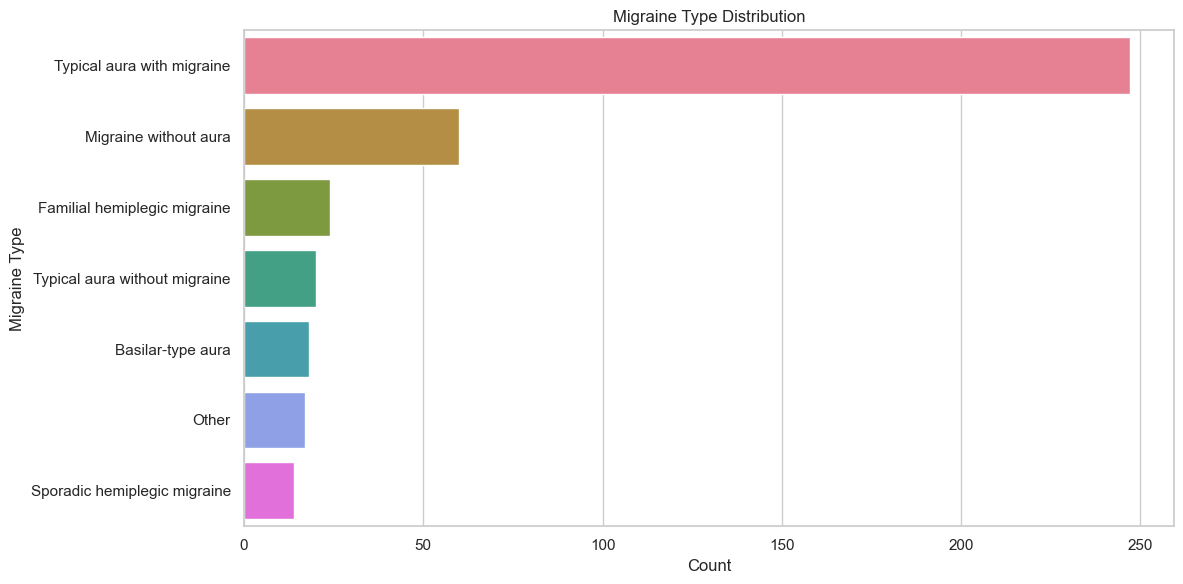

In [5]:
target_counts = df[TARGET].value_counts()
target_percent = (df[TARGET].value_counts(normalize=True) * 100).round(2)
target_summary = pd.DataFrame({'count': target_counts, 'percent': target_percent})
display(target_summary)

ax = sns.barplot(
    x=target_counts.values,
    y=target_counts.index,
    hue=target_counts.index,
    legend=False,
)
ax.set_title('Migraine Type Distribution')
ax.set_xlabel('Count')
ax.set_ylabel('Migraine Type')
plt.tight_layout()
plt.show()

## Feature Distributions

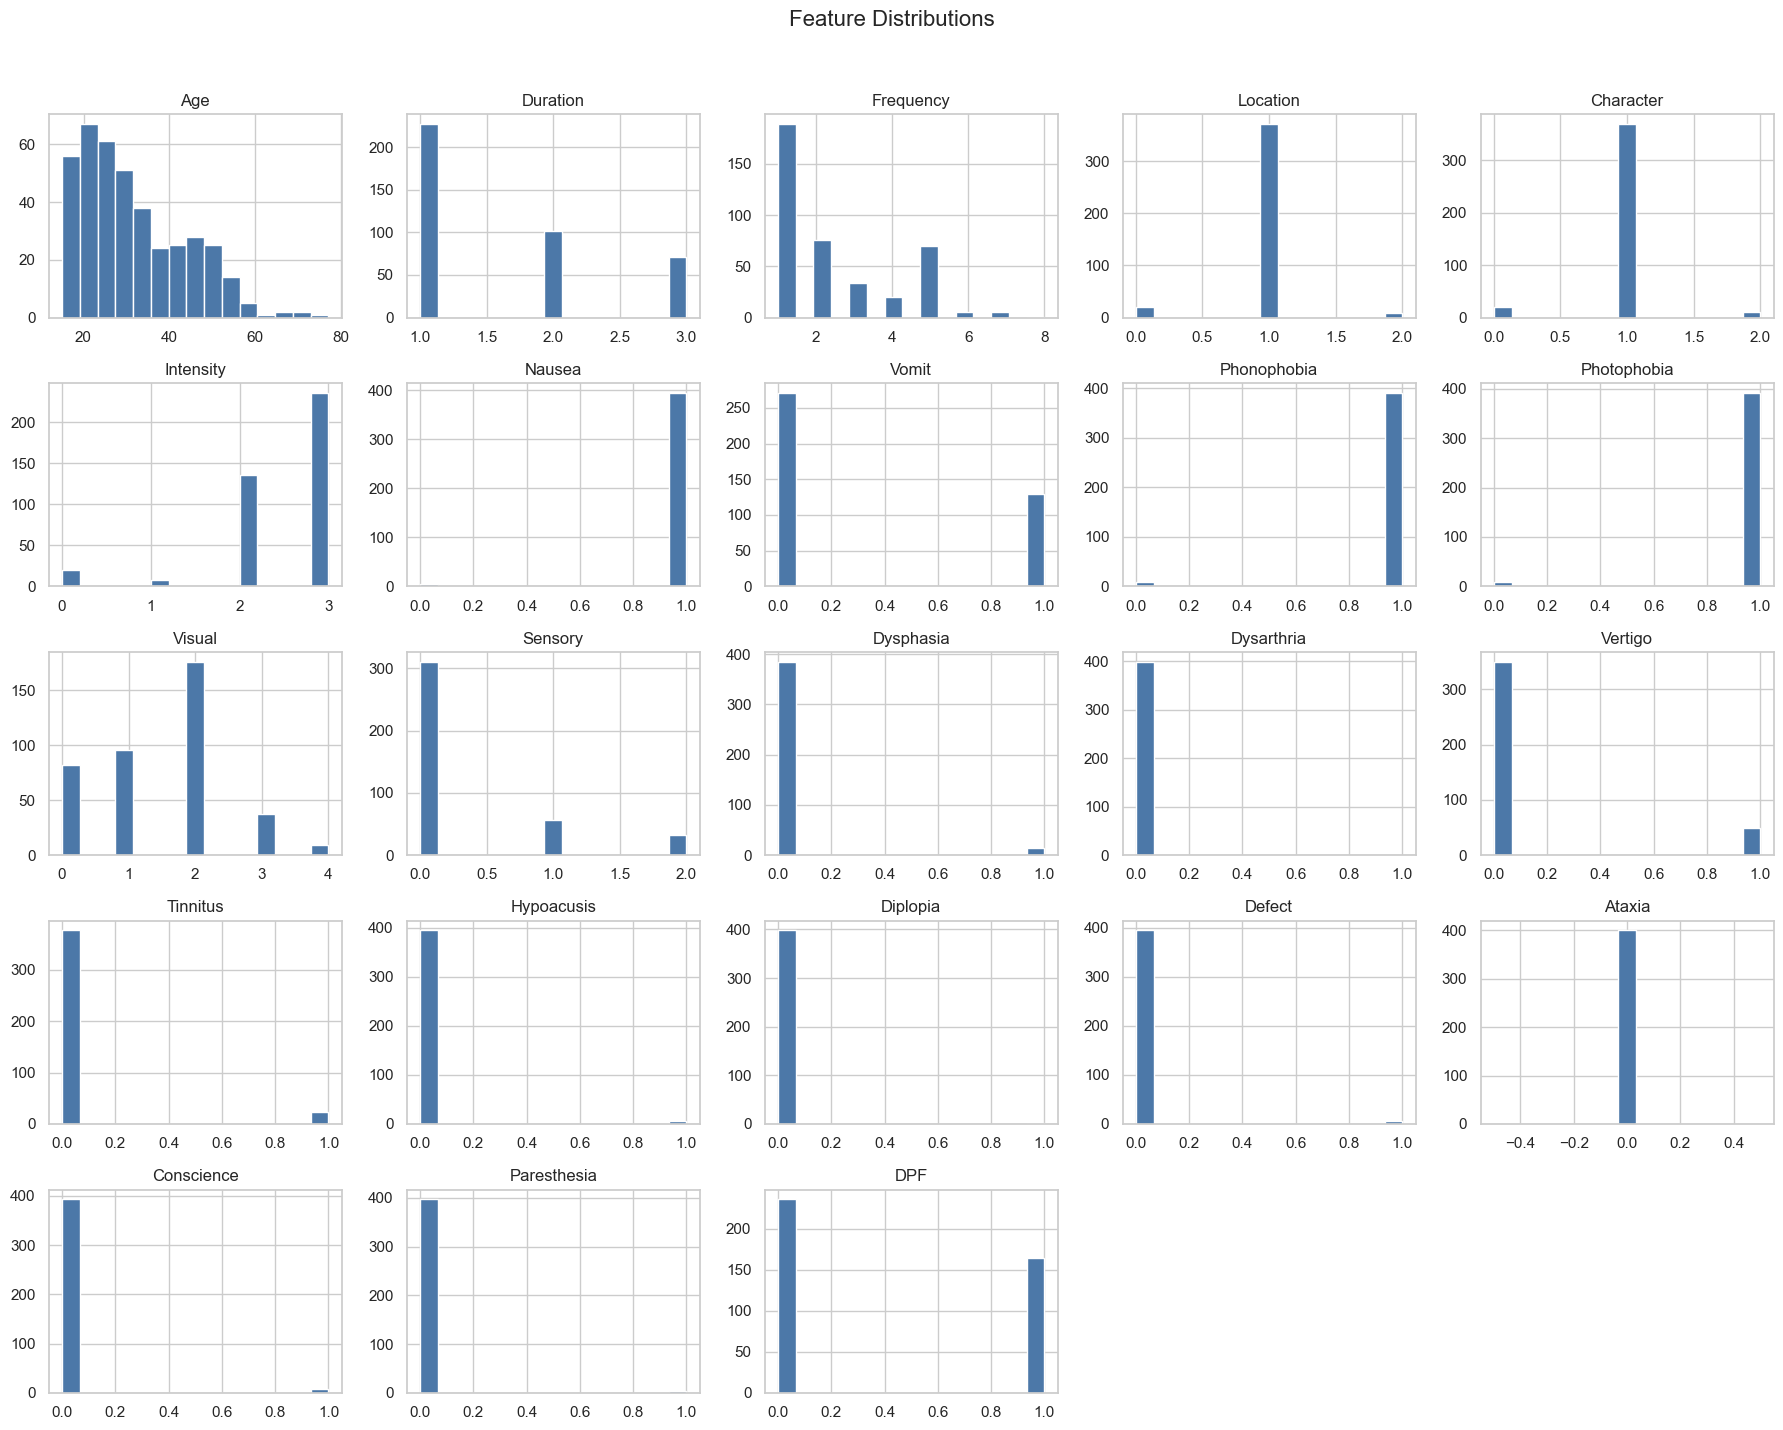

In [6]:
numeric_features = df[FEATURES].select_dtypes(include='number').columns.tolist()

df[numeric_features].hist(bins=15, figsize=(18, 14), color='#4c78a8', edgecolor='white')
plt.suptitle('Feature Distributions', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## Feature Values by Migraine Type

The heatmap below shows average feature values per target class. It is useful for spotting which symptoms or measurements are more common in each migraine type.

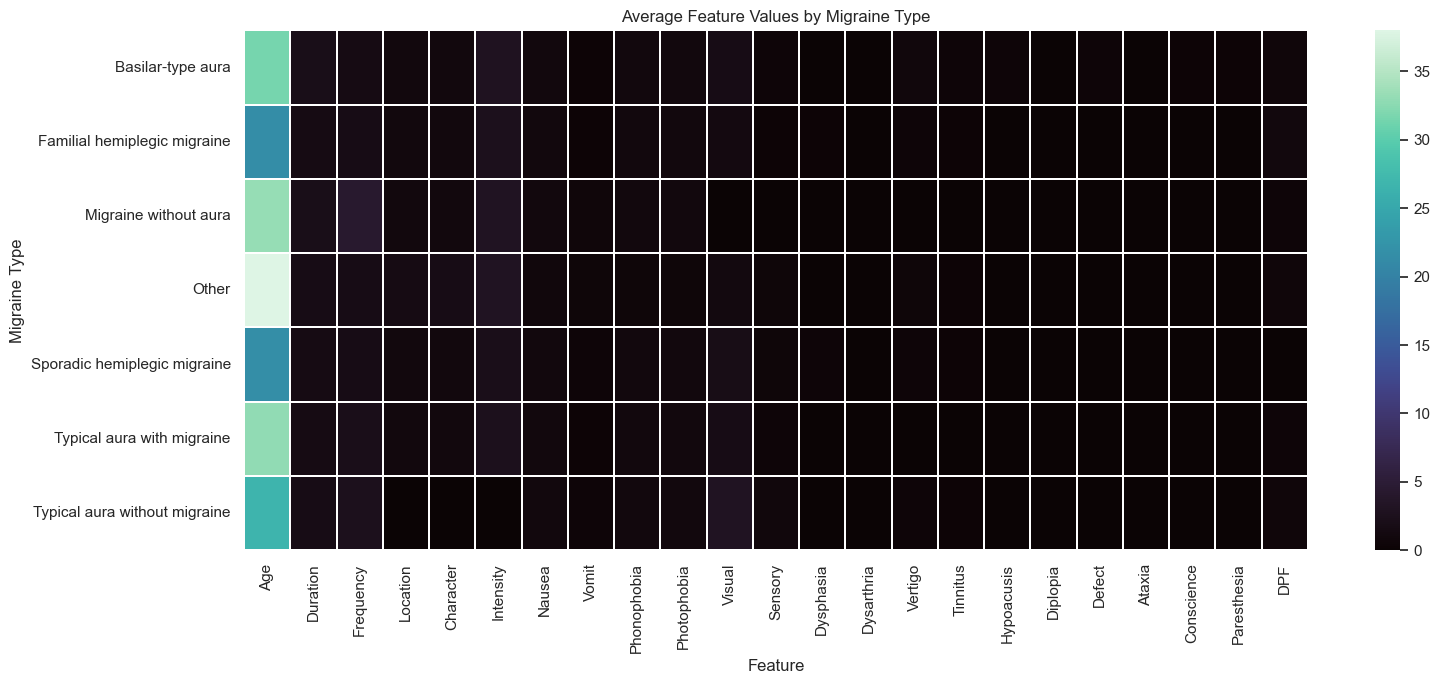

In [7]:
class_feature_means = df.groupby(TARGET)[FEATURES].mean()

plt.figure(figsize=(16, 7))
sns.heatmap(class_feature_means, cmap='mako', linewidths=0.3)
plt.title('Average Feature Values by Migraine Type')
plt.xlabel('Feature')
plt.ylabel('Migraine Type')
plt.tight_layout()
plt.show()

## Correlation Heatmap

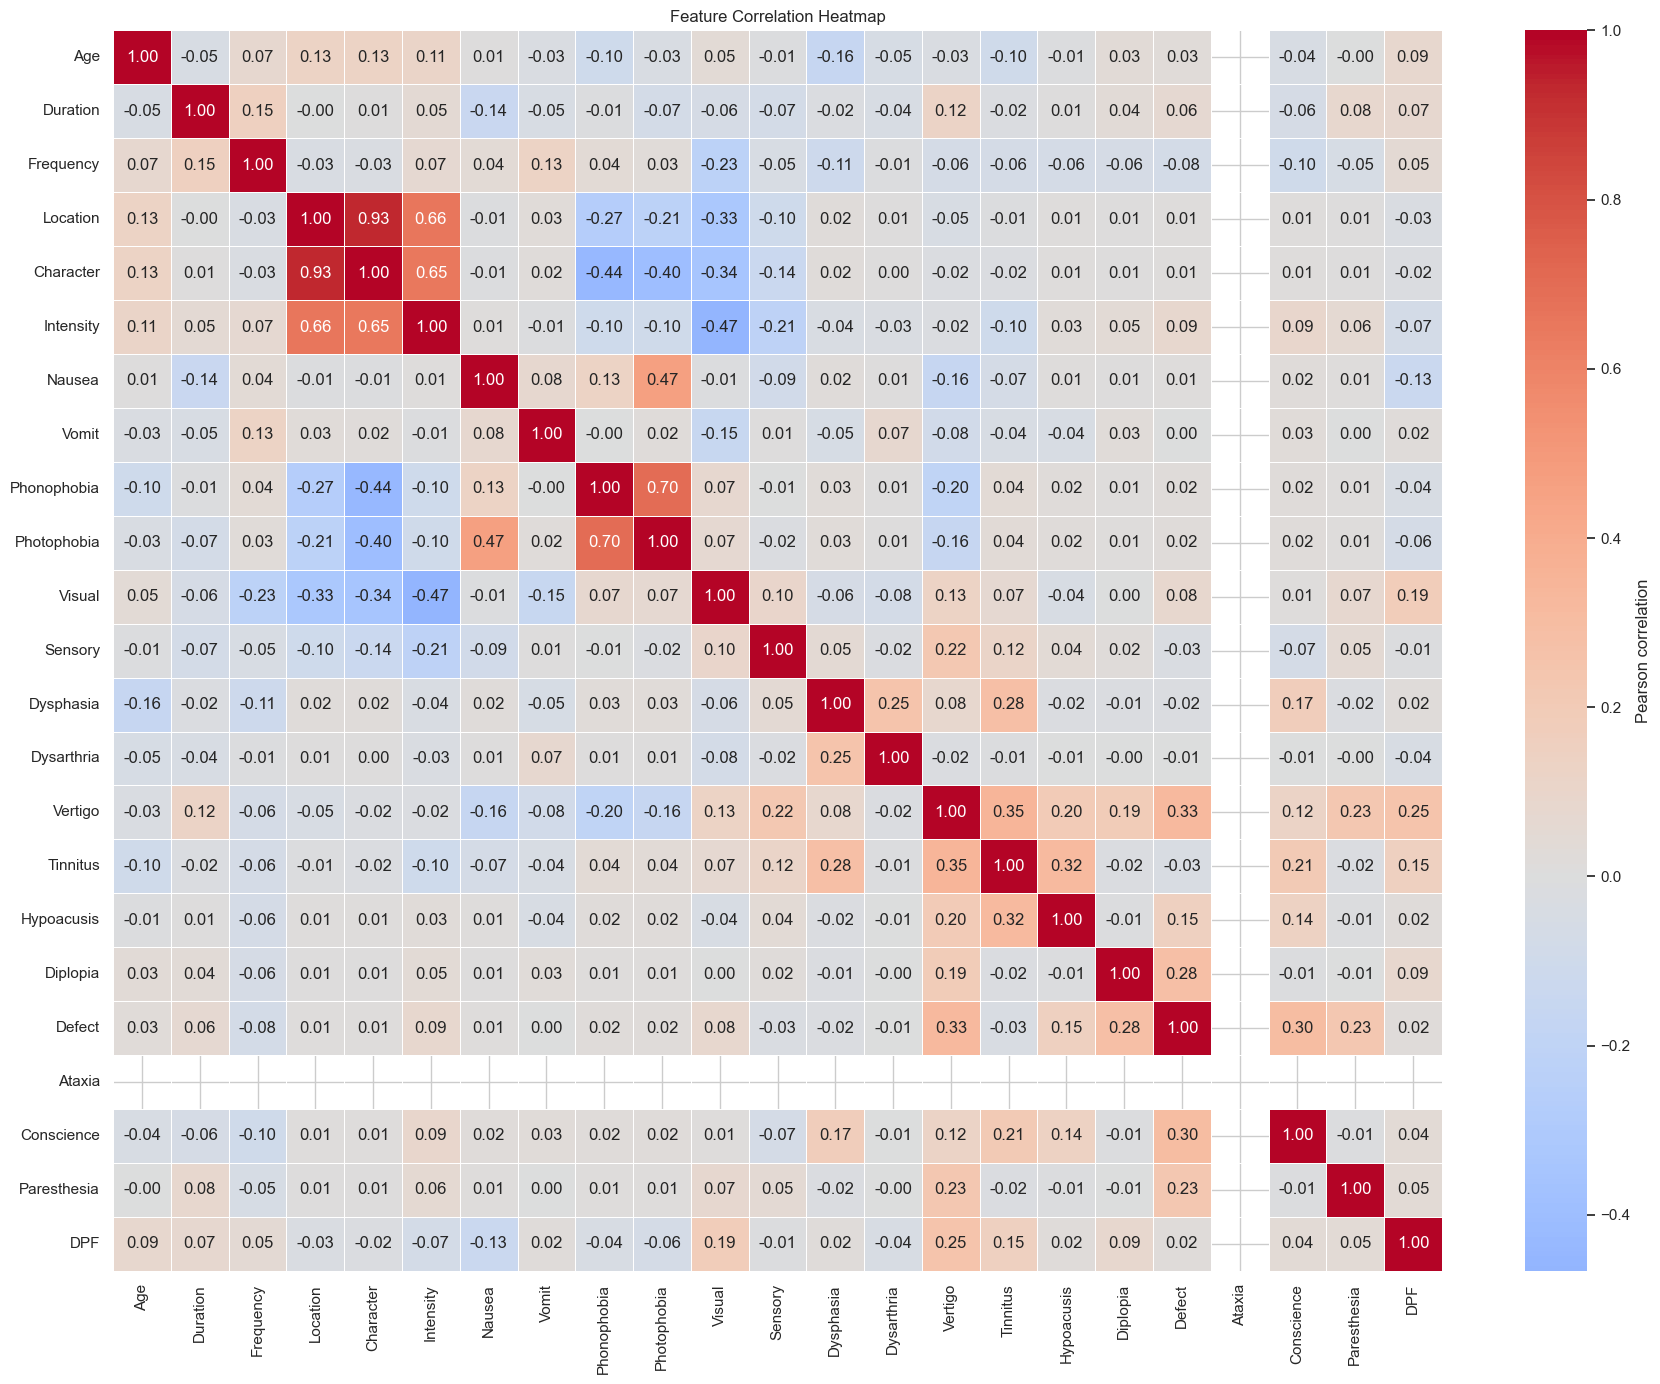

In [8]:
corr = df[FEATURES].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    cbar_kws={'label': 'Pearson correlation'},
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Strongest Feature Correlations

In [9]:
corr_pairs = (
    corr.where(~pd.DataFrame(False, index=corr.index, columns=corr.columns).mask(
        pd.DataFrame(False, index=corr.index, columns=corr.columns).values
    ))
)
upper_triangle = corr.where(pd.DataFrame(
    [[i < j for j in range(len(corr.columns))] for i in range(len(corr.index))],
    index=corr.index,
    columns=corr.columns,
))
strongest_pairs = (
    upper_triangle.stack()
    .rename('correlation')
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'})
)
strongest_pairs['absolute_correlation'] = strongest_pairs['correlation'].abs()
display(strongest_pairs.sort_values('absolute_correlation', ascending=False).head(15))

,feature_1,feature_2,correlation,absolute_correlation
73,Location,Character,0.933517,0.933517
193,Phonophobia,Photophobia,0.700786,0.700786
74,Location,Intensity,0.658737,0.658737
97,Character,Intensity,0.648325,0.648325
147,Nausea,Photophobia,0.466108,0.466108
125,Intensity,Visual,-0.466105,0.466105
100,Character,Phonophobia,-0.437568,0.437568
101,Character,Photophobia,-0.397716,0.397716
337,Vertigo,Tinnitus,0.350134,0.350134
102,Character,Visual,-0.342347,0.342347


## Boxplots for Continuous and Ordinal Features

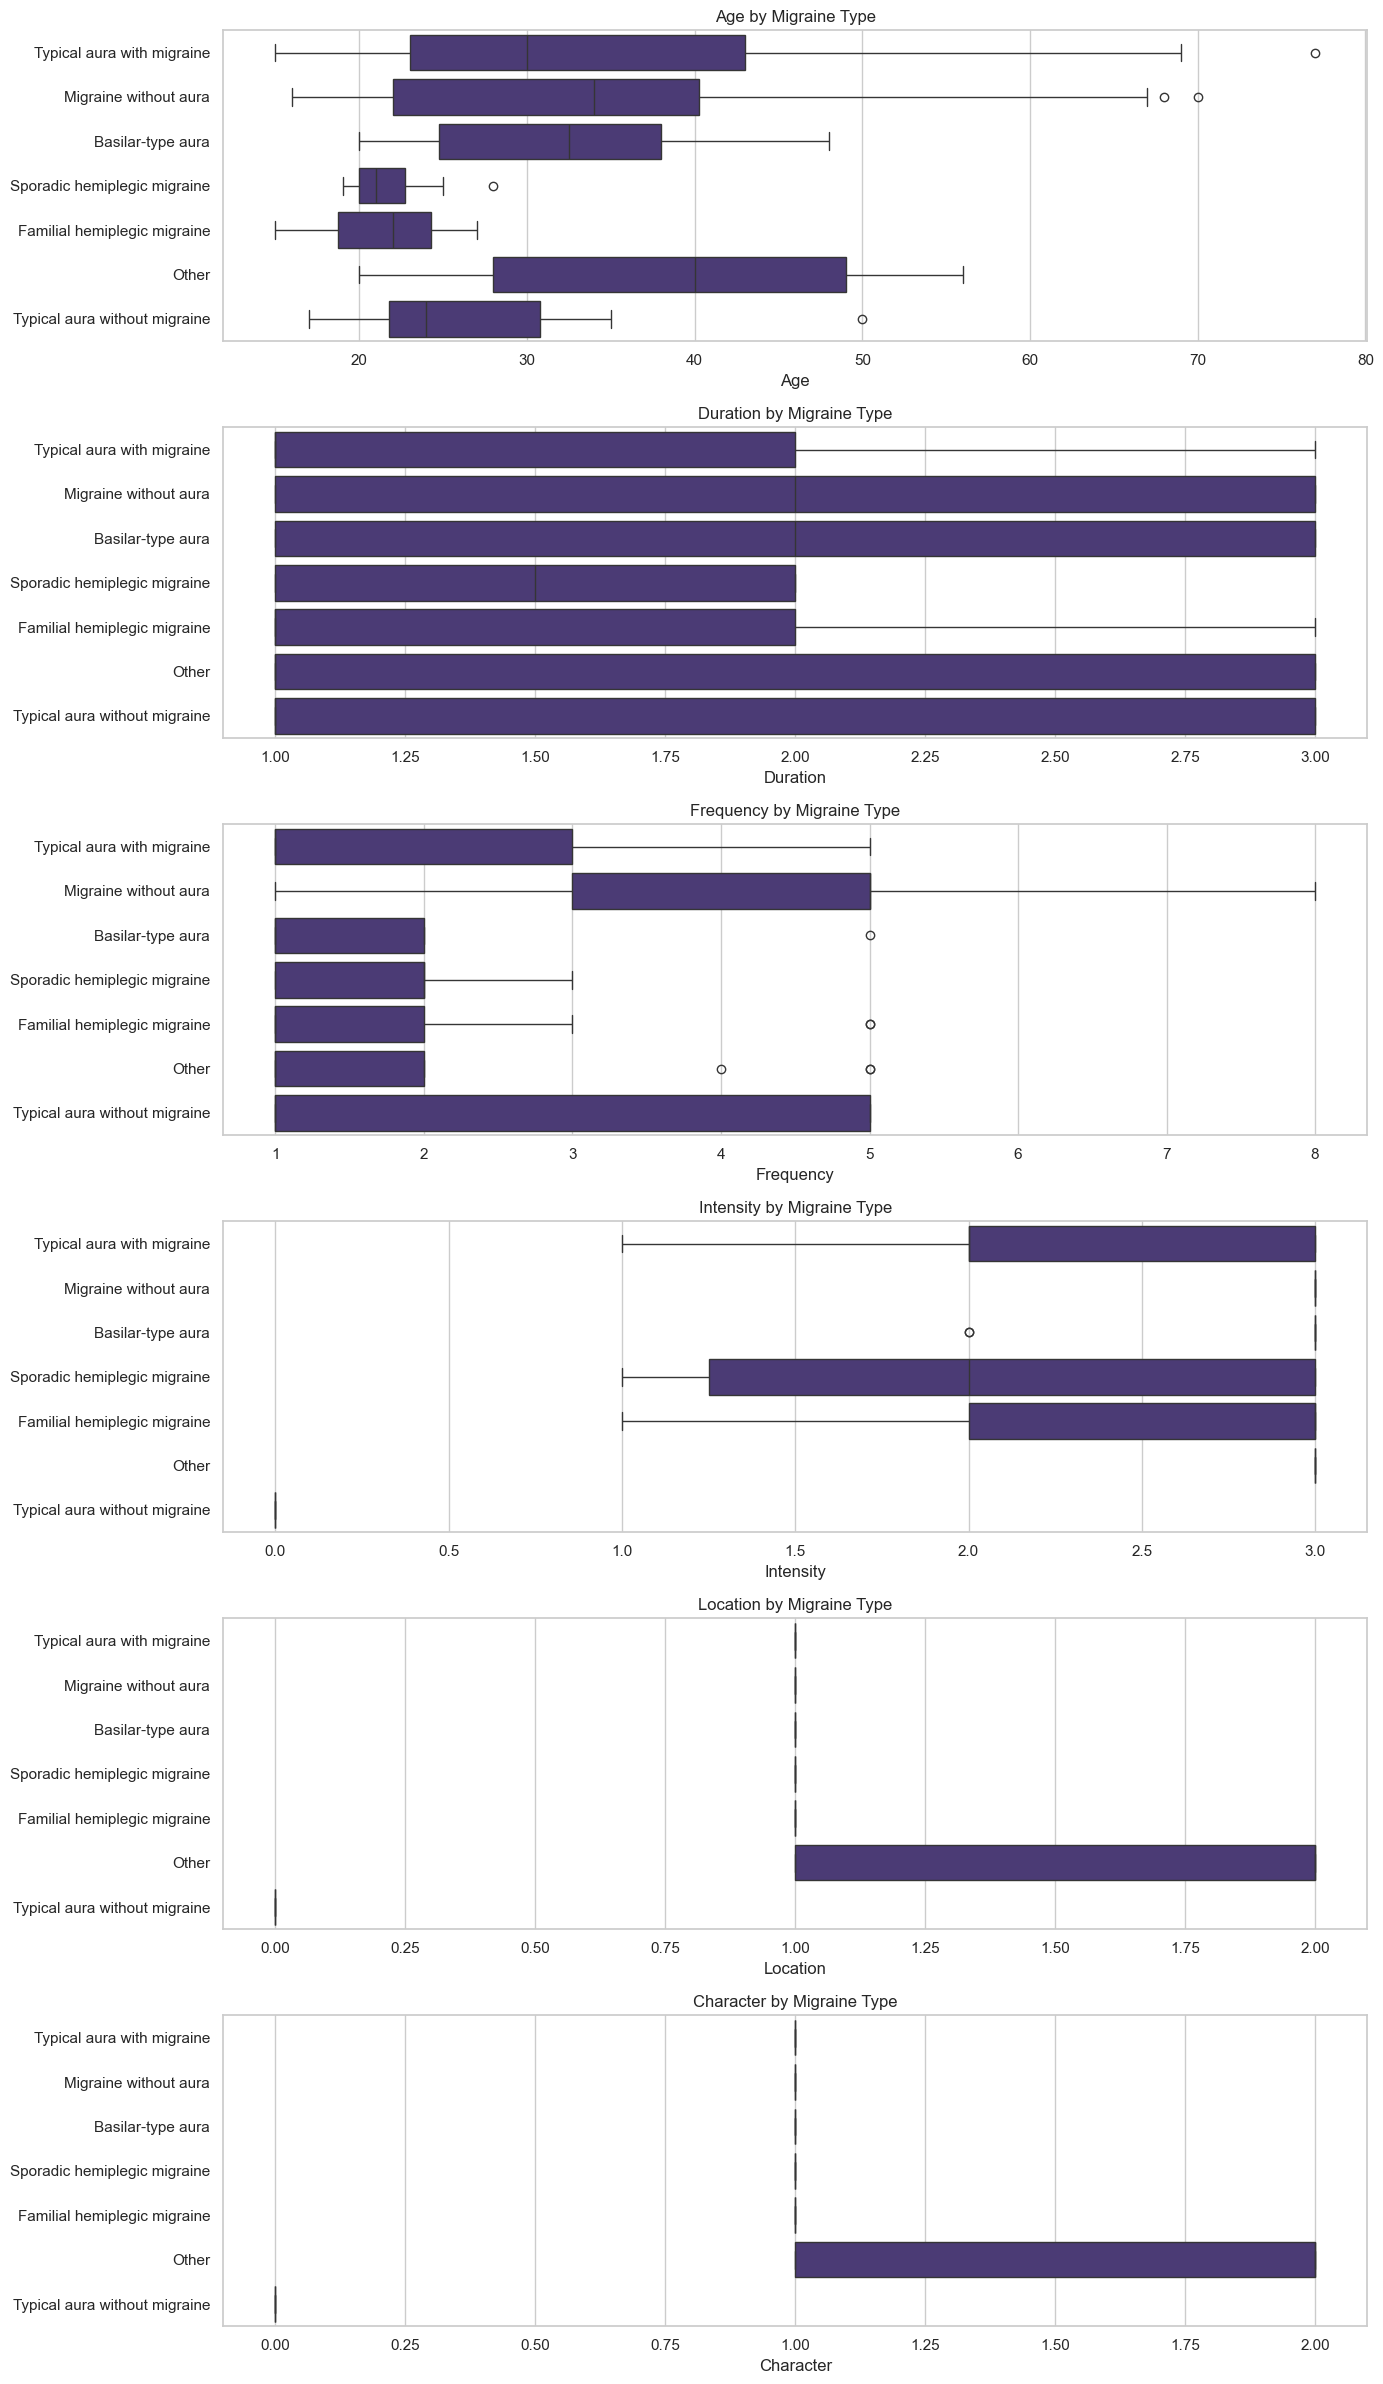

In [10]:
boxplot_features = ['Age', 'Duration', 'Frequency', 'Intensity', 'Location', 'Character']
available_boxplot_features = [feature for feature in boxplot_features if feature in df.columns]

fig, axes = plt.subplots(
    nrows=len(available_boxplot_features),
    ncols=1,
    figsize=(14, 4 * len(available_boxplot_features)),
)

if len(available_boxplot_features) == 1:
    axes = [axes]

for ax, feature in zip(axes, available_boxplot_features):
    sns.boxplot(data=df, x=feature, y=TARGET, ax=ax)
    ax.set_title(f'{feature} by Migraine Type')
    ax.set_xlabel(feature)
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

## Symptom Prevalence by Migraine Type

Most symptom columns are binary or small ordinal values. This chart compares the average value of each symptom feature across migraine types.

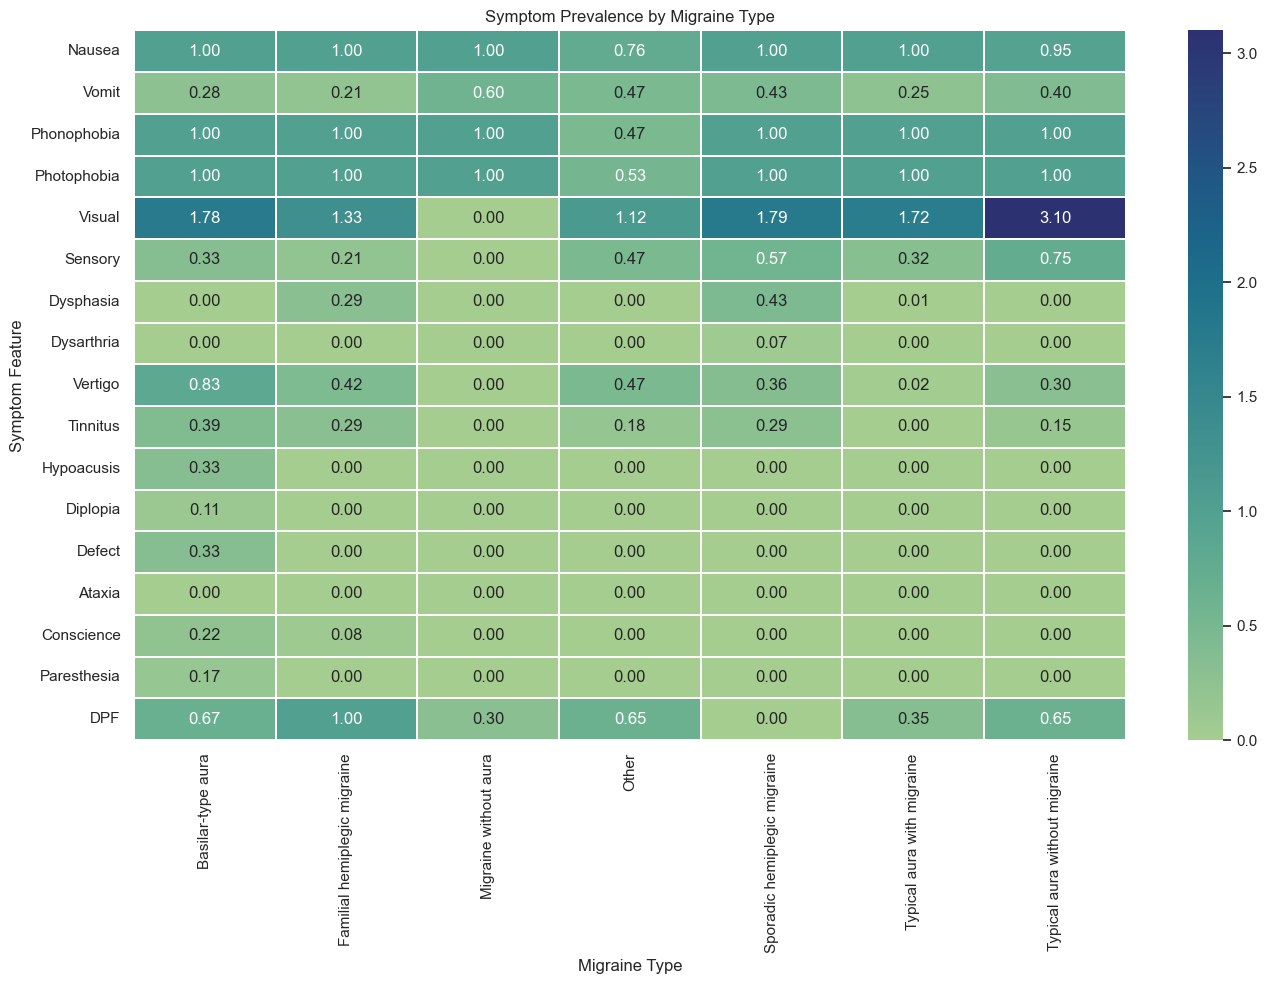

In [11]:
symptom_features = [
    feature for feature in FEATURES
    if feature not in ['Age', 'Duration', 'Frequency', 'Location', 'Character', 'Intensity']
]
symptom_means = df.groupby(TARGET)[symptom_features].mean().T

plt.figure(figsize=(14, 10))
sns.heatmap(symptom_means, cmap='crest', annot=True, fmt='.2f', linewidths=0.3)
plt.title('Symptom Prevalence by Migraine Type')
plt.xlabel('Migraine Type')
plt.ylabel('Symptom Feature')
plt.tight_layout()
plt.show()

## Random Forest Feature Importance

Feature importance is calculated with a Random Forest trained on the full dataset for exploratory interpretation. This should be treated as an EDA signal, not final model evaluation.

,feature,importance
0,Visual,0.129197
1,Intensity,0.106578
2,Age,0.100071
3,Character,0.094525
4,Location,0.086526
5,DPF,0.073309
6,Frequency,0.060745
7,Vertigo,0.057324
8,Phonophobia,0.035491
9,Dysphasia,0.035093


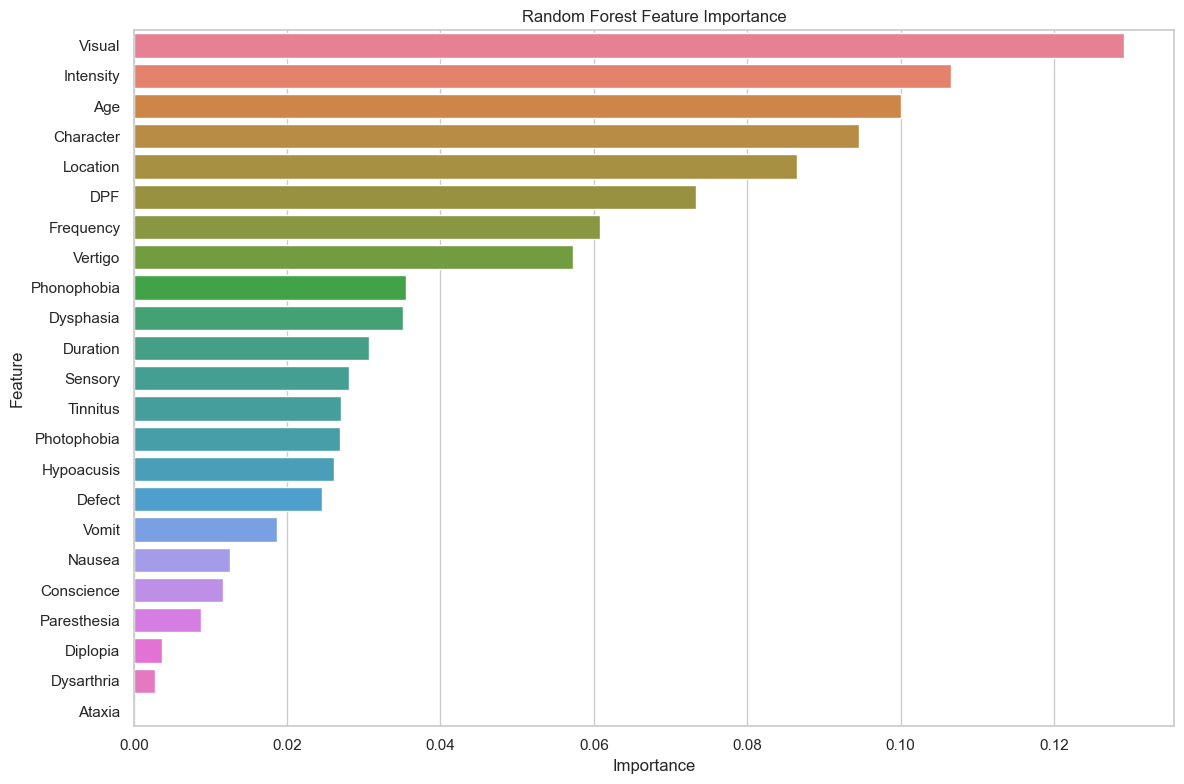

In [12]:
X = df[FEATURES]
y = df[TARGET]

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    max_features='sqrt',
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
)
rf.fit(X, y)

importance = (
    pd.DataFrame({'feature': FEATURES, 'importance': rf.feature_importances_})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
display(importance)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance, x='importance', y='feature', hue='feature', legend=False)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## EDA Notes Template

Use this section to record the main observations after running the notebook.

- Target balance: note whether one migraine type dominates the dataset.
- Data quality: note missing values, duplicates, or suspicious ranges.
- Correlations: list highly correlated feature pairs and possible redundancy.
- Feature importance: list the top features from the Random Forest plot.
- Class patterns: describe symptoms/features that differ strongly by migraine type.